# **Preparation**

In [1]:
# !pip install torch transformers datasets librosa soundfile jiwer matplotlib seaborn pandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 40.3 MB/s eta 0:00:00


In [2]:
import torch
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from datasets import load_dataset
from jiwer import wer
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Informasi Perangkat:")
print(f"   - Perangkat yang digunakan: {device}")
if device.type == "cuda":
    print(f"   - GPU: {torch.cuda.get_device_name(0)}")
    print(f"   - VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   - ⚠️ GPU tidak tersedia, proses akan lebih lambat. Disarankan menggunakan Runtime -> Change runtime type -> T4 GPU")

Informasi Perangkat:
   - Perangkat yang digunakan: cuda
   - GPU: Tesla T4
   - VRAM: 15.64 GB


## **Load Model & Dataset**

In [10]:
# Load dataset dari Hugging Face
dataset = load_dataset("evanarlian/common_voice_11_0_id_filtered", split="train")

print(f"Dataset berhasil dimuat")
print(f"Nama dataset: Common Voice 11.0 (Indonesia - Filtered)")
print(f"Jumlah total sampel: {len(dataset)}")
print(f"Kolom yang tersedia: {dataset.column_names}")
print(f"Sample rate audio: {dataset[0]['audio']['sampling_rate']} Hz")

print("\nPreview 5 sampel pertama:")
for i in range(5):
    print(f"   [{i+1}] {dataset[i]['sentence'][:70]}...")

Dataset berhasil dimuat
Nama dataset: Common Voice 11.0 (Indonesia - Filtered)
Jumlah total sampel: 22906
Kolom yang tersedia: ['client_id', 'path', 'audio', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'locale', 'segment']
Sample rate audio: 16000 Hz

Preview 5 sampel pertama:
   [1] halo dunia!...
   [2] Sudah makan? sudah sholat...?...
   [3] udah keluar hasil testnya?...
   [4] Dimanakah sate paling enak di Jakarta Selatan?...
   [5] coba terus sampai berhasil...


In [5]:
# Load model dan processor
model_name = "m-salman-a/wav2vec2-xlsr-53-common-voice-indonesian"
print(f"Model: {model_name}")

processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name)
model.to(device)

print(f"\nModel berhasil dimuat")
print(f"Arsitektur: Wav2Vec2-XLSR-53")
print(f"Jumlah parameter: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"Bahasa: Indonesia (fine-tuned on Common Voice)")
print(f"Device: {device}")

Model: m-salman-a/wav2vec2-xlsr-53-common-voice-indonesian


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]


Model berhasil dimuat
Arsitektur: Wav2Vec2-XLSR-53
Jumlah parameter: 315.5M
Bahasa: Indonesia (fine-tuned on Common Voice)
Device: cuda


# **PROCESS**

## **Mendefinisikan Fungsi**

In [12]:
def preprocess_sample(sample, target_sr=16000):
    # Proses audio
    speech_array = sample["audio"]["array"]
    sampling_rate = sample["audio"]["sampling_rate"]

    # Resample jika perlu (dari 48kHz ke 16kHz)
    if sampling_rate != target_sr:
        speech_array = librosa.resample(
            speech_array,
            orig_sr=sampling_rate,
            target_sr=target_sr
        )

    # Normalisasi audio (agar nilai antara -1 dan 1)
    if np.abs(speech_array).max() > 0:
        speech_array = speech_array / np.abs(speech_array).max()

    # Bersihkan ground truth (sentence)
    sentence = sample["sentence"]
    sentence_clean = re.sub(r'[^\w\s]', '', sentence)
    sentence_clean = sentence_clean.lower()
    sentence_clean = re.sub(r'\s+', ' ', sentence_clean)
    sentence_clean = sentence_clean.strip()

    return {
        "speech": speech_array.astype(np.float32),
        "ground_truth": sentence_clean,
        "duration": len(speech_array) / target_sr,
        "original_sentence": sentence
    }

print("Preprocess Data Berhasil")

Preprocess Data Berhasil


In [13]:
def transcribe_sample(speech, processor, model, device, target_sr=16000):
    # Proses dengan processor
    inputs = processor(
        speech,
        sampling_rate=target_sr,
        return_tensors="pt",
        padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Prediksi (tanpa menghitung gradient untuk efisiensi)
    with torch.no_grad():
        logits = model(**inputs).logits

    # Decode hasil
    predicted_ids = torch.argmax(logits, dim=-1)
    transcription = processor.batch_decode(predicted_ids)[0]

    return transcription

print("Fungsi transkripsi berhasil didefinisikan")

Fungsi transkripsi berhasil didefinisikan


## **Sample Prep**

In [17]:
# Konfigurasi eksperimen
N_SAMPLES = 100

print(f"Konfigurasi Eksperimen:")
print(f"Jumlah sampel: {N_SAMPLES}")
print(f"Total dataset tersedia: {len(dataset)}")
print(f"Persentase yang digunakan: {N_SAMPLES/len(dataset)*100:.2f}%")

# Pilih sampel secara acak
np.random.seed(42)

# Generate indeks random dan konversi ke int biasa
random_indices = np.random.choice(len(dataset), N_SAMPLES, replace=False)
indices = [int(idx) for idx in random_indices]

print(f"\nMengambil sampel dengan indeks:")
print(f"Indeks pertama: {indices[0]}")
print(f"Indeks terakhir: {indices[-1]}")

# Ambil sampel berdasarkan indeks
raw_samples = []
for idx in indices:
    raw_samples.append(dataset[idx])

print(f"\n{len(raw_samples)} sampel berhasil dipilih secara acak")

# Preprocessing semua sampel
print("\nMelakukan preprocessing...")
processed_samples = []
for i, sample in enumerate(raw_samples):
    processed = preprocess_sample(sample)
    processed["sample_id"] = i
    processed_samples.append(processed)

    # Tampilkan progress setiap 20 sampel
    if (i + 1) % 20 == 0:
        print(f"   Progress: {i+1}/{N_SAMPLES} sampel")

print(f"\nPreprocessing selesai untuk {len(processed_samples)} sampel")

# Hitung statistik durasi
durations = [s["duration"] for s in processed_samples]
print(f"\nStatistik Durasi Audio:")
print(f"Rata-rata: {np.mean(durations):.2f} detik")
print(f"Min: {np.min(durations):.2f} detik")
print(f"Max: {np.max(durations):.2f} detik")
print(f"Std Dev: {np.std(durations):.2f} detik")

Konfigurasi Eksperimen:
Jumlah sampel: 100
Total dataset tersedia: 22906
Persentase yang digunakan: 0.44%

Mengambil sampel dengan indeks:
Indeks pertama: 20792
Indeks terakhir: 14838

100 sampel berhasil dipilih secara acak

Melakukan preprocessing...
   Progress: 20/100 sampel
   Progress: 40/100 sampel
   Progress: 60/100 sampel
   Progress: 80/100 sampel
   Progress: 100/100 sampel

Preprocessing selesai untuk 100 sampel

Statistik Durasi Audio:
Rata-rata: 4.06 detik
Min: 1.98 detik
Max: 9.65 detik
Std Dev: 1.23 detik


## **Transcribe**

In [18]:
print("Memulai proses transkripsi...")

results = []

for i, sample in enumerate(processed_samples):
    # Tampilkan progress setiap 10 sampel
    if (i + 1) % 10 == 0:
        print(f"   Progress: {i+1}/{N_SAMPLES} sampel ({((i+1)/N_SAMPLES)*100:.0f}%)")

    # Transkripsi
    try:
        prediction = transcribe_sample(
            sample["speech"],
            processor,
            model,
            device
        )

        # Hitung WER
        error_rate = wer(sample["ground_truth"], prediction)

        # Simpan hasil
        results.append({
            "sample_id": sample["sample_id"] + 1,
            "duration": sample["duration"],
            "ground_truth": sample["ground_truth"],
            "prediction": prediction,
            "wer": error_rate,
            "original_sentence": sample["original_sentence"]
        })
    except Exception as e:
        print(f"Error pada sampel {i+1}: {e}")
        results.append({
            "sample_id": sample["sample_id"] + 1,
            "duration": sample["duration"],
            "ground_truth": sample["ground_truth"],
            "prediction": "[ERROR]",
            "wer": 1.0,  # WER maksimum untuk error
            "original_sentence": sample["original_sentence"]
        })

print(f"\nTranskripsi selesai!")
print(f"Berhasil diproses: {len(results)} sampel")


Memulai proses transkripsi...
   Progress: 10/100 sampel (10%)
   Progress: 20/100 sampel (20%)
   Progress: 30/100 sampel (30%)
   Progress: 40/100 sampel (40%)
   Progress: 50/100 sampel (50%)
   Progress: 60/100 sampel (60%)
   Progress: 70/100 sampel (70%)
   Progress: 80/100 sampel (80%)
   Progress: 90/100 sampel (90%)
   Progress: 100/100 sampel (100%)

Transkripsi selesai!
Berhasil diproses: 100 sampel


## **Statistic**

In [20]:
# Konversi ke DataFrame
df_results = pd.DataFrame(results)

# Statistik dasar
avg_wer = df_results["wer"].mean()
std_wer = df_results["wer"].std()
min_wer = df_results["wer"].min()
max_wer = df_results["wer"].max()
median_wer = df_results["wer"].median()

print(f"\nSTATISTIK WORD ERROR RATE (WER):")
print(f"Rata-rata WER     : {avg_wer*100:.2f}%")
print(f"Standar Deviasi   : {std_wer*100:.2f}%")
print(f"WER Terendah      : {min_wer*100:.2f}%")
print(f"WER Tertinggi     : {max_wer*100:.2f}%")
print(f"Median WER        : {median_wer*100:.2f}%")

# Kategorikan performa berdasarkan WER
def categorize_wer(wer):
    if wer < 0.2:
        return "Baik (WER < 20%)"
    elif wer < 0.5:
        return "Sedang (20% ≤ WER < 50%)"
    else:
        return "Buruk (WER ≥ 50%)"

df_results["performance"] = df_results["wer"].apply(categorize_wer)
performance_counts = df_results["performance"].value_counts()

print(f"\nDISTRIBUSI PERFORMANCE:")
for cat, count in performance_counts.items():
    print(f"   {cat}: {count} sampel ({count/N_SAMPLES*100:.1f}%)")


STATISTIK WORD ERROR RATE (WER):
Rata-rata WER     : 16.34%
Standar Deviasi   : 19.13%
WER Terendah      : 0.00%
WER Tertinggi     : 75.00%
Median WER        : 13.39%

DISTRIBUSI PERFORMANCE:
   Baik (WER < 20%): 59 sampel (59.0%)
   Sedang (20% ≤ WER < 50%): 31 sampel (31.0%)
   Buruk (WER ≥ 50%): 10 sampel (10.0%)


## **Analyze**

In [23]:
# Kelompokkan berdasarkan durasi
df_results["duration_group"] = pd.cut(
    df_results["duration"],
    bins=[0, 2, 4, 6, 10, 100],
    labels=["<2 detik", "2-4 detik", "4-6 detik", "6-10 detik", ">10 detik"]
)

duration_stats = df_results.groupby("duration_group", observed=True)["wer"].agg(["mean", "std", "count"])
duration_stats["mean_percent"] = duration_stats["mean"] * 100
duration_stats["std_percent"] = duration_stats["std"] * 100

print(f"Rata-rata WER berdasarkan durasi audio:")
for group in duration_stats.index:
    if pd.notna(group):
        mean_val = duration_stats.loc[group, "mean_percent"]
        std_val = duration_stats.loc[group, "std_percent"]
        count_val = duration_stats.loc[group, "count"]
        print(f"   {group:12} : {mean_val:.2f}% ({std_val:.2f}%) | n={count_val}")

# Korelasi antara durasi dan WER
correlation = df_results["duration"].corr(df_results["wer"])
print(f"\nKorelasi antara durasi dan WER: {correlation:.3f}")
if correlation > 0:
    print("Semakin panjang durasi, semakin tinggi WER (akurasi menurun)")
else:
    print("Semakin pendek durasi, semakin tinggi WER")

Rata-rata WER berdasarkan durasi audio:
   <2 detik     : 0.00% (nan%) | n=1
   2-4 detik    : 11.71% (16.36%) | n=61
   4-6 detik    : 22.22% (20.71%) | n=30
   6-10 detik   : 31.67% (21.51%) | n=8

Korelasi antara durasi dan WER: 0.358
Semakin panjang durasi, semakin tinggi WER (akurasi menurun)


## **Transcribe Output**

In [25]:
# Tampilkan 5 sampel terbaik
best_samples = df_results.nsmallest(5, "wer")
print("SAMPEL DENGAN WER TERENDAH (TERBAIK):")
for i, row in best_samples.iterrows():
    print(f"\nSample #{int(row['sample_id'])} (Durasi: {row['duration']:.1f}s, WER: {row['wer']*100:.1f}%)")
    print(f"Ground Truth: {row['ground_truth'][:80]}")
    print(f"Prediction  : {row['prediction'][:80]}")

# Tampilkan 5 sampel terburuk
worst_samples = df_results.nlargest(5, "wer")
print("\n\n5 SAMPEL DENGAN WER TERTINGGI (TERBURUK):")
for i, row in worst_samples.iterrows():
    print(f"\nSample #{int(row['sample_id'])} (Durasi: {row['duration']:.1f}s, WER: {row['wer']*100:.1f}%)")
    print(f"Ground Truth: {row['ground_truth'][:80]}")
    print(f"Prediction  : {row['prediction'][:80]}")

SAMPEL DENGAN WER TERENDAH (TERBAIK):

Sample #1 (Durasi: 3.8s, WER: 0.0%)
Ground Truth: kalau dari sini pergi sedikit ke barat ada laut
Prediction  : kalau dari sini pergi sedikit ke barat ada laut

Sample #3 (Durasi: 3.1s, WER: 0.0%)
Ground Truth: belajar bahasa tidaklah mudah
Prediction  : belajar bahasa tidaklah mudah

Sample #6 (Durasi: 3.7s, WER: 0.0%)
Ground Truth: saya sedih jika kamu berkata seperti itu
Prediction  : saya sedih jika kamu berkata seperti itu

Sample #7 (Durasi: 4.4s, WER: 0.0%)
Ground Truth: saya menolong adik perempuan saya membuat pekerjaan rumah
Prediction  : saya menolong adik perempuan saya membuat pekerjaan rumah

Sample #13 (Durasi: 3.8s, WER: 0.0%)
Ground Truth: gadis yang berdiri di sana adalah mary
Prediction  : gadis yang berdiri di sana adalah mary


5 SAMPEL DENGAN WER TERTINGGI (TERBURUK):

Sample #27 (Durasi: 5.4s, WER: 75.0%)
Ground Truth: saya belum bisa bicara bahasa indonesia dengan lancar
Prediction  : saya bebisa belecara bahasa indonesi a 

## **Visualisasi Hasil**

Histogram Distribusi WER


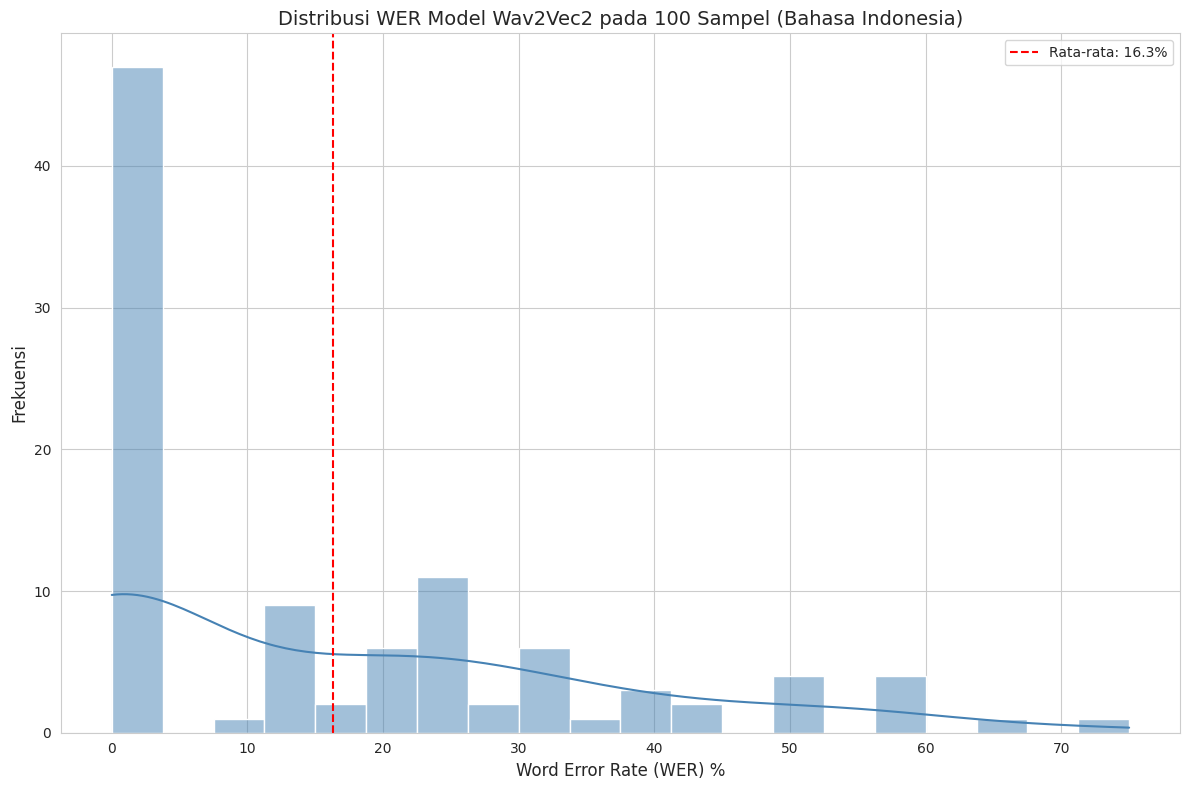

In [26]:
# Setup style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Histogram Distribusi WER
fig1, ax1 = plt.subplots()
sns.histplot(df_results["wer"] * 100, bins=20, kde=True, ax=ax1, color='steelblue')
ax1.set_xlabel("Word Error Rate (WER) %", fontsize=12)
ax1.set_ylabel("Frekuensi", fontsize=12)
ax1.set_title(f"Distribusi WER Model Wav2Vec2 pada {N_SAMPLES} Sampel (Bahasa Indonesia)", fontsize=14)
ax1.axvline(avg_wer*100, color='red', linestyle='--', label=f'Rata-rata: {avg_wer*100:.1f}%')
ax1.legend()
plt.tight_layout()
plt.savefig("1_wer_distribution.png", dpi=150)
print("Histogram Distribusi WER")

Scatter Plot WER vs Durasi Audio


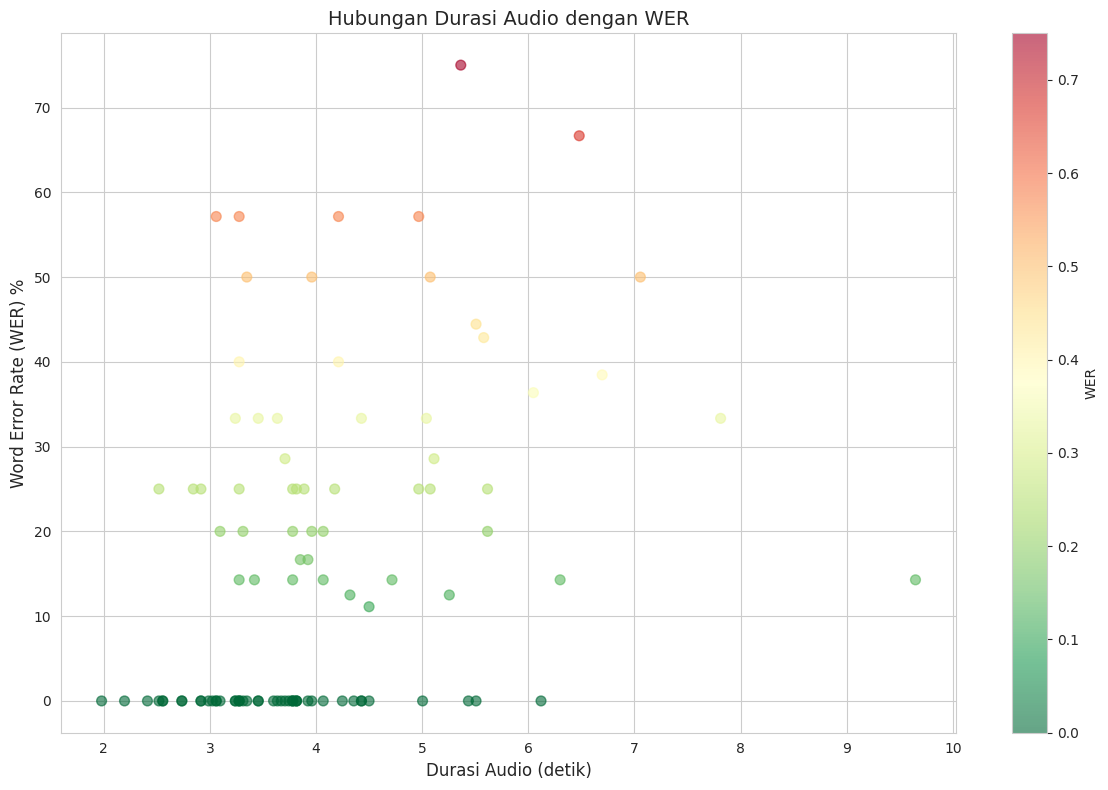

In [27]:
# Scatter Plot WER vs Durasi Audio
fig2, ax2 = plt.subplots()
scatter = ax2.scatter(df_results["duration"], df_results["wer"] * 100,
                      alpha=0.6, c=df_results["wer"], cmap='RdYlGn_r', s=50)
ax2.set_xlabel("Durasi Audio (detik)", fontsize=12)
ax2.set_ylabel("Word Error Rate (WER) %", fontsize=12)
ax2.set_title("Hubungan Durasi Audio dengan WER", fontsize=14)
plt.colorbar(scatter, label="WER")
plt.tight_layout()
plt.savefig("2_wer_vs_duration_scatter.png", dpi=150)
print("Scatter Plot WER vs Durasi Audio")

Pie Chart Distribusi Performance


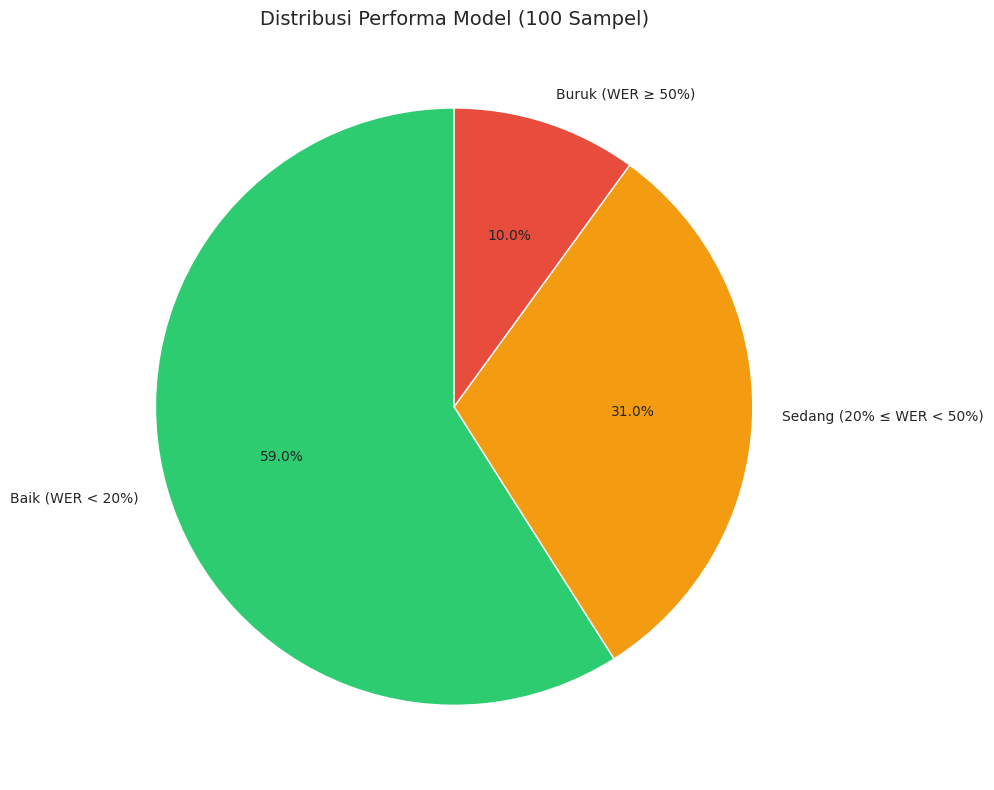

In [31]:
# Pie Chart Distribusi Performance
fig5, ax5 = plt.subplots()
colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
wedges, texts, autotexts = ax5.pie(
    performance_counts.values,
    labels=performance_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90
)
ax5.set_title(f"Distribusi Performa Model ({N_SAMPLES} Sampel)", fontsize=14)
plt.tight_layout()
plt.savefig("5_performance_piechart.png", dpi=150)
print("Pie Chart Distribusi Performance")

# **Save Model**

In [32]:
# Simpan DataFrame ke CSV
df_results.to_csv("asr_experiment_results.csv", index=False)
print("asr_experiment_results.csv (detail per sampel)")

# Simpan ringkasan statistik
summary_stats = pd.DataFrame({
    "Metrik": [
        "Jumlah Sampel",
        "Rata-rata WER (%)",
        "Standar Deviasi (%)",
        "Min WER (%)",
        "Max WER (%)",
        "Median WER (%)",
        "Korelasi Durasi-WER"
    ],
    "Nilai": [
        N_SAMPLES,
        f"{avg_wer*100:.2f}",
        f"{std_wer*100:.2f}",
        f"{min_wer*100:.2f}",
        f"{max_wer*100:.2f}",
        f"{median_wer*100:.2f}",
        f"{correlation:.3f}"
    ]
})
summary_stats.to_csv("wer_statistics.csv", index=False)
print("wer_statistics.csv (ringkasan statistik)")

# Simpan statistik per durasi
duration_stats_clean = duration_stats.reset_index()
duration_stats_clean.to_csv("duration_analysis.csv", index=False)
print("duration_analysis.csv (analisis per durasi)")

print("\nFile yang telah disimpan:")
print("asr_experiment_results.csv")
print("wer_statistics.csv")
print("duration_analysis.csv")
print("1_wer_distribution.png")
print("2_wer_vs_duration_scatter.png")
print("5_performance_piechart.png")

asr_experiment_results.csv (detail per sampel)
wer_statistics.csv (ringkasan statistik)
duration_analysis.csv (analisis per durasi)

File yang telah disimpan:
asr_experiment_results.csv
wer_statistics.csv
duration_analysis.csv
1_wer_distribution.png
2_wer_vs_duration_scatter.png
5_performance_piechart.png
